# Part 3: Memory Management & GPU Profiling

---

## Section 3.1 - GPU Memory Architecture & Management

In this section you will learn:
- How CPU and GPU memory are connected and why the PCIe bus is the bottleneck
- How to move data between CPU and GPU in PyTorch
- How PyTorch's caching allocator manages VRAM
- How to measure transfer costs and optimize them with pinned memory & async transfers

#### Setup - import helper functions

All reusable utility functions live in `../src/gpu_helpers.py`. 

All profiled scripts and output profiler files live in `../data`.

In [2]:
import sys, os, shutil
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.profiler import profile, ProfilerActivity
from IPython.display import FileLink, display as ipy_display
sys.path.insert(0, os.path.abspath('../src'))
OUTPUT_DIR = '../data'
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [3]:
import importlib
import gpu_helpers
gpu_helpers = importlib.reload(gpu_helpers)

from gpu_helpers import (
    print_gpu_memory, print_peak_memory, reset_gpu_memory,
    benchmark_transfers, compare_pinned_vs_pageable,
    plot_transfer_benchmarks,
    cuda_timer, profiler_to_df, nsys_sqlite_to_chrome_trace
)

### 3.1.1 Environment check

In [4]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"Device name:        {props.name}")
    print(f"CUDA version:       {torch.version.cuda}")
    print(f"Total VRAM:         {props.total_memory / 1e9:.1f} GB")
    print(f"Streaming multip.:  {props.multi_processor_count}")
    print(f"Compute cap.:       {props.major}.{props.minor}")
else:
    raise RuntimeError("GPU not available!")

PyTorch version: 2.4.1+cu121
CUDA available:  True
Device name:        NVIDIA A100-SXM4-40GB
CUDA version:       12.1
Total VRAM:         42.6 GB
Streaming multip.:  108
Compute cap.:       8.0


### 3.1.2 Memory architecture overview

The diagram below shows the key components of the CPU–GPU memory architecture:

```
  ┌──────────────────────────────┐                    ┌──────────────────────────────┐
  │             CPU              │                    │             GPU              │
  │                              │                    │                              │
  │   ┌──────────────────────┐   │                    │   ┌──────────────────────┐   │
  │   │         RAM          │   │    PCIe Bus        │   │        VRAM          │   │
  │   │   ~50–100 GB/s       │   │◄──────────────────►│   │   ~900–2000 GB/s     │   │
  │   │  (pageable by        │   │   ~16–32 GB/s      │   │   (on-chip, fast)    │   │
  │   │   default)           │   │                    │   │                      │   │
  │   └──────────────────────┘   │                    │   └──────────────────────┘   │
  └──────────────────────────────┘                    └──────────────────────────────┘

                              bottleneck ↑
                         60–120x slower than VRAM
```

**Key takeaway:** The PCIe bus is the bottleneck. GPU memory bandwidth is **~60-120x** higher
than the PCIe link. Therefore, **minimizing CPU<->GPU transfers** is priority.

### 3.1.3 Where are tensors stored? - CPU vs. GPU

Every PyTorch tensor has a `device` attribute. Data can reside on the CPU (`cpu`)
or on a GPU (`cuda:0`, `cuda:1`, ...).  
A tensor **cannot** participate in an operation with a tensor on a different device:

In [5]:
# Tensor on CPU (default)
a_cpu = torch.randn(1000, 1000)
print(f"a_cpu.device = {a_cpu.device}")

# Tensor on GPU - three equivalent ways
a_gpu_1 = a_cpu.to('cuda')                              # idiomatic
a_gpu_2 = a_cpu.cuda()                                  # shorthand
a_gpu_3 = torch.randn(1000, 1000, device='cuda')        # created directly on GPU

print(f"a_gpu_1.device = {a_gpu_1.device}")
print(f"a_gpu_2.device = {a_gpu_2.device}")
print(f"a_gpu_3.device = {a_gpu_3.device}")

a_cpu.device = cpu
a_gpu_1.device = cuda:0
a_gpu_2.device = cuda:0
a_gpu_3.device = cuda:0


In [6]:
# What happens when we try to add a CPU tensor to a GPU tensor
try:
    result = a_cpu + a_gpu_1
except RuntimeError as e:
    print(f"Error! {e}")

Error! Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!


### 3.1.4 Monitoring GPU memory

PyTorch exposes functions to check VRAM usage. The key distinction:

- **`memory_allocated`** - how much memory is currently occupied by tensors
- **`memory_reserved`** - how much memory the caching allocator has reserved (always >= allocated)

PyTorch uses a **caching allocator**: instead of returning memory to CUDA after deleting a tensor,
it keeps it "on standby" for future allocations. This speeds things up but can be misleading.

In [7]:
# Clean up previous tensors
del a_gpu_1, a_gpu_2, a_gpu_3
reset_gpu_memory()

In [8]:
print_gpu_memory("After deleting a_gpu_1, a_gpu_2, a_gpu_3")

[After deleting a_gpu_1, a_gpu_2, a_gpu_3]  allocated:      0.0 MB  |  reserved:      0.0 MB


In [9]:
# Watch how memory changes with allocations

print_gpu_memory("before allocation")

# Allocate a 1000x1000 float32 tensor ~= 4 MB
x = torch.randn(1000, 1000, device='cuda')
print_gpu_memory("after x (4 MB)")

# Allocate a larger 5000x5000 float32 tensor = 100 MB
y = torch.randn(5000, 5000, device='cuda')
print_gpu_memory("after y (100 MB)")

# Delete y
del y
print_gpu_memory("after del y")
print("Allocated dropped, but reserved stayed - caching allocation.")

# Force memory return to CUDA
torch.cuda.empty_cache()
print_gpu_memory("after empty_cache()")
del x
print_gpu_memory("after del x")
torch.cuda.synchronize()
print_gpu_memory("after cuda.synchronize()")
torch.cuda.empty_cache()
print_gpu_memory("after cuda.empty_cache()")

[        before allocation]  allocated:      0.0 MB  |  reserved:      0.0 MB
[           after x (4 MB)]  allocated:      4.0 MB  |  reserved:     21.0 MB
[         after y (100 MB)]  allocated:    104.7 MB  |  reserved:    121.6 MB
[              after del y]  allocated:      4.0 MB  |  reserved:    121.6 MB
Allocated dropped, but reserved stayed - caching allocation.
[      after empty_cache()]  allocated:      4.0 MB  |  reserved:     21.0 MB
[              after del x]  allocated:      0.0 MB  |  reserved:     21.0 MB
[ after cuda.synchronize()]  allocated:      0.0 MB  |  reserved:     21.0 MB
[ after cuda.empty_cache()]  allocated:      0.0 MB  |  reserved:      0.0 MB


### 3.1.5 Measuring CPU <-> GPU transfer cost

Transferring data over the PCIe bus has a cost that grows with size - but also with various
protocol overheads, so achieved bandwidth climbs toward the PCIe theoretical limit only for
larger transfers. Let's measure this empirically.

Important: GPU operations are **asynchronous** - we must use `torch.cuda.Event` for correct timing.


In [10]:
# The timing mechanism: cuda.Event records GPU-side timestamps
# (unlike time.perf_counter, which returns immediately before the GPU finishes)

data_demo = torch.randn(1000, 1000)   # 4 MB, pageable RAM

start_event = torch.cuda.Event(enable_timing=True)
end_event   = torch.cuda.Event(enable_timing=True)

start_event.record()
_ = data_demo.to('cuda')          # CPU -> GPU transfer
end_event.record()
torch.cuda.synchronize()          # wait for GPU to finish

print(f"Single 4 MB CPU->GPU transfer: {start_event.elapsed_time(end_event):.2f} ms")
del data_demo, _

# Full benchmark: measure_transfer_time() wraps the above pattern,
# repeating each measurement 20x and returning the median.
sizes_mb, times_to_gpu, times_from_gpu, bandwidths = benchmark_transfers()

sizes = [100, 500, 1000, 2000, 3000, 5000, 7000, 10000]
print(f"\n{'Size':>12s} | {'MB':>8s} | {'CPU->GPU (ms)':>12s} | {'GPU->CPU (ms)':>12s} | {'BW (GB/s)':>10s}")
print("-" * 65)
for s, mb, t1, t2, bw in zip(sizes, sizes_mb, times_to_gpu, times_from_gpu, bandwidths):
    print(f"{s:>5d}x{s:<5d} | {mb:>8.1f} | {t1:>12.2f} | {t2:>12.2f} | {bw:>10.1f}")
print("\nNote: GPU->CPU transfers are slower than CPU->GPU - CUDA must synchronize before DMA can read results back.")

Single 4 MB CPU->GPU transfer: 0.83 ms

        Size |       MB | CPU->GPU (ms) | GPU->CPU (ms) |  BW (GB/s)
-----------------------------------------------------------------
  100x100   |      0.0 |         0.04 |         0.04 |        0.9
  500x500   |      1.0 |         0.15 |         0.15 |        6.8
 1000x1000  |      4.0 |         0.33 |         0.35 |       12.2
 2000x2000  |     16.0 |         1.43 |         1.28 |       11.2
 3000x3000  |     36.0 |         3.26 |         6.16 |       11.1
 5000x5000  |    100.0 |         7.72 |        16.56 |       13.0
 7000x7000  |    196.0 |        14.79 |        33.04 |       13.3
10000x10000 |    400.0 |        30.47 |        65.67 |       13.1

Note: GPU->CPU transfers are slower than CPU->GPU - CUDA must synchronize before DMA can read results back.


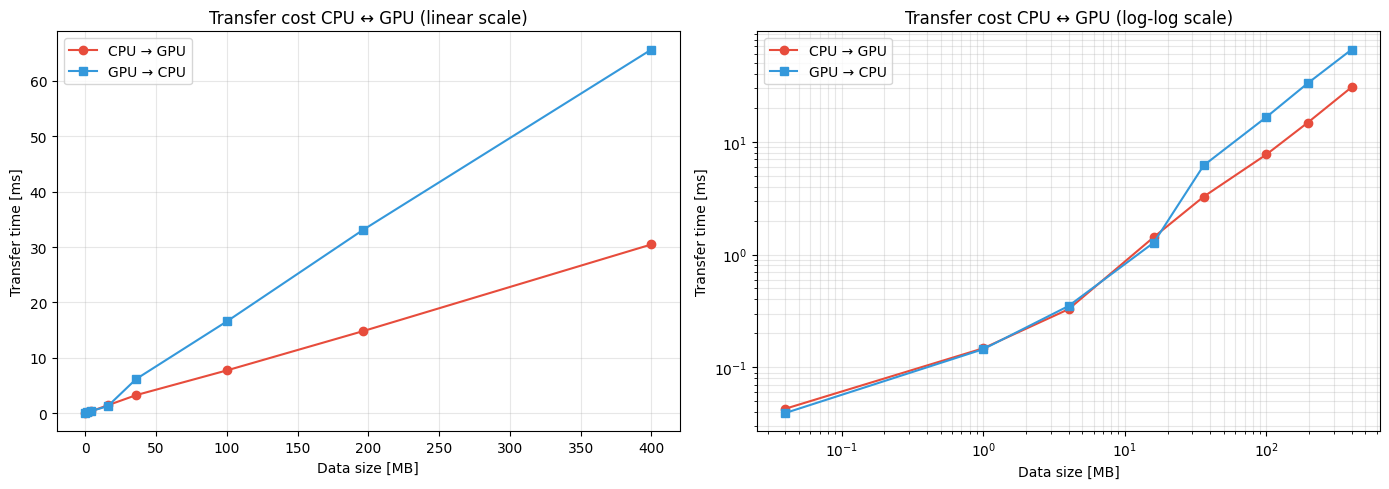


Estimated CPU->GPU bandwidth (largest tensor): 13.1 GB/s


In [11]:
# Visualize: transfer time vs data size
plot_transfer_benchmarks(sizes_mb, times_to_gpu, times_from_gpu)

print(f"\nEstimated CPU->GPU bandwidth (largest tensor): {bandwidths[-1]:.1f} GB/s")

### 3.1.6 Pinned memory - faster transfers

**Virtual memory and pages:**
The OS manages RAM in fixed-size blocks called **pages** (typically 4 KB). Each page has a virtual address - what your program sees - mapped to a physical address - the actual location in RAM. The OS can remap this mapping at any time.

**Pageable memory** means pages can be moved to **swap** - a reserved area on disk - when physical RAM is full. The OS transparently moves idle pages to disk and loads them back on demand. Programs see a consistent virtual address, but the underlying physical address can change.

**Why pinned memory is required:**
When transferring data to the GPU, CUDA reads directly from RAM using physical addresses. With pageable memory, the OS could move a page mid-transfer - changing its physical address and corrupting the data. **Pinned (page-locked) memory** is fixed in place: the OS cannot swap or remap it, so the address stays valid for the entire transfer.

**What happens without pinned memory:**
CUDA runtime handles this automatically, but at a cost:
1. Allocates a temporary pinned buffer internally
2. Copies: pageable -> pinned  (on CPU)
3. DMA transfer: pinned -> GPU VRAM

```
Default:     Pageable RAM  ─>  [temp Pinned]  ─>  GPU VRAM   (2 copies)
Pin memory:  Pinned RAM    ──────────────────────> GPU VRAM   (1 copy)
```

**When does pinned memory actually save copies?**
- `torch.randn(N, N).pin_memory()` - generates data in pageable RAM, then copies to pinned. For data used **only once**: the total number of copies is the same, just shifted in time.
- Real benefit: data **reused multiple times** (DataLoader, multiple training epochs). You pay the pinning cost once; every subsequent transfer is a direct DMA.
- Direct pinned allocation: `torch.empty(N, N).pin_memory()` - uninitialized tensor allocated directly in pinned memory, no intermediate pageable buffer.

**Tradeoff:** pinned memory cannot be swapped by the OS - allocating too much can starve the system.

In [12]:
# Quick check: is_pinned()
data_pageable = torch.randn(1000, 1000)
data_pinned   = torch.randn(1000, 1000).pin_memory()

print(f"data_pageable.is_pinned() = {data_pageable.is_pinned()}")
print(f"data_pinned.is_pinned()   = {data_pinned.is_pinned()}")

data_pageable.is_pinned() = False
data_pinned.is_pinned()   = True


In [13]:
# Compare pageable vs pinned transfer for a single size
size = 5000
mb = (size * size * 4) / 1e6
t_pageable, t_pinned = compare_pinned_vs_pageable(size)

print(f"Transfer {mb:.0f} MB:")
print(f"  Pageable: {t_pageable:.2f} ms")
print(f"  Pinned:   {t_pinned:.2f} ms")
print(f"  Speedup:  {t_pageable / t_pinned:.2f}x")

Transfer 100 MB:
  Pageable: 7.78 ms
  Pinned:   4.36 ms
  Speedup:  1.78x


### 3.1.7 Async transfers and CUDA Streams

**The default stream bottleneck:**
Every GPU operation - memory transfer, kernel launch - goes into **stream 0** (the default stream).
Operations in the same stream execute in order, one at a time:

```
Default stream (serial):
  [ transfer 0 ]──►[ compute 0 ]──►[ transfer 1 ]──►[ compute 1 ]──► ...
```

To overlap transfers with computation we need two things: **`non_blocking=True`** and **CUDA Streams**.

---

**Step 1 - Pinned memory** (from 3.1.6): eliminates the intermediate CPU copy. Each transfer is faster, but everything is still serial on the default stream.

**Step 2 - `non_blocking=True`**: the CPU returns immediately after scheduling the transfer command without waiting for it to finish. Internally, PyTorch places the transfer on a separate copy stream. However, the compute op still sits on the default stream - which implicitly waits for the copy stream to finish before proceeding. The result: no substantial GPU-side benefit.

**Step 3 - Explicit CUDA Streams**: a `Stream` is a separate GPU queue. Operations on different streams can run in parallel if the GPU has free resources (e.g. copy engine and compute engine simultaneously):

```
Two streams (pipelined):
  copy stream:    [ transfer 0 ]──►[ transfer 1 ]──►[ transfer 2 ]──► ...
  default stream:               ──►[ compute 0  ]──►[ compute 1  ]──► ...
                                    ↑ overlap ↑
```

**In practice:** `DataLoader` with `pin_memory=True` and many streams handles all of this automatically.

In [14]:
reset_gpu_memory()
print_gpu_memory("Before asynchronous transfer tests")

[Before asynchronous transfer tests]  allocated:      0.0 MB  |  reserved:      0.0 MB


In [15]:
N = 2048
num_batches = 10
batches_pag = [torch.randn(N, N)             for _ in range(num_batches)]  # pageable
batches_pin = [torch.randn(N, N).pin_memory() for _ in range(num_batches)]  # pinned
W = torch.randn(N, N, device='cuda')

def run_pageable():
    for batch in batches_pag:
        b_gpu = batch.to('cuda')          # blocking, pageable -> temp pinned -> GPU
        torch.mm(b_gpu, W)
    torch.cuda.synchronize()

In [16]:
def run_pinned_sync():
    for batch in batches_pin:
        b_gpu = batch.to('cuda')          # blocking, pinned -> GPU directly
        torch.mm(b_gpu, W)
    torch.cuda.synchronize()

In [17]:
def run_pipelined():
    # create a dedicated stream for transfers (separate from the default compute stream)
    s = torch.cuda.Stream()

    # pre-fetch batch 0 so the first iteration has data ready immediately
    with torch.cuda.stream(s):
        cur = batches_pin[0].to('cuda', non_blocking=True)

    for i in range(num_batches):
        if i + 1 < num_batches:
            # schedule next transfer on the copy stream - runs in parallel with compute below
            with torch.cuda.stream(s):
                nxt = batches_pin[i + 1].to('cuda', non_blocking=True)
        else:
            nxt = None

        # insert dependency: default stream will not proceed until stream s finishes cur
        torch.cuda.current_stream().wait_stream(s)
        # compute on default stream - copy stream is already working on the next batch
        torch.mm(cur, W)
        # swap buffers: cur becomes the batch that was being transferred
        cur = nxt

    torch.cuda.synchronize()

In [18]:
t_pag      = cuda_timer(run_pageable,    num_repeats=10)
t_sync     = cuda_timer(run_pinned_sync, num_repeats=10)
t_pipeline = cuda_timer(run_pipelined,   num_repeats=10)

print(f"Pageable + blocking:   {t_pag:.1f} ms")
print(f"Pinned   + blocking:   {t_sync:.1f} ms")
print(f"Pinned   + streams:    {t_pipeline:.1f} ms")

del batches_pag, batches_pin, W
reset_gpu_memory()

Pageable + blocking:   24.2 ms
Pinned   + blocking:   16.6 ms
Pinned   + streams:    11.3 ms


In [19]:
print_gpu_memory()

[                         ]  allocated:      0.0 MB  |  reserved:      0.0 MB


### 3.1.8 Section summary

| Topic | Key takeaway |
|---|---|
| **Architecture** | PCIe (~16–32 GB/s) is the bottleneck between CPU and GPU (VRAM ~900–2000 GB/s) |
| **Monitoring** | `memory_allocated` vs `memory_reserved` - caching allocator reserves more than needed |
| **Transfer cost** | Bandwidth grows with size, approaches PCIe limit for large tensors; GPU->CPU slower than CPU->GPU; measure with `cuda.Event`! |
| **Pinned memory** | Eliminates extra copy step, requires `.pin_memory()` |
| **non_blocking** | Enables overlapping transfers with computation, works with pinned memory |
| **CUDA Streams** | Separate GPU queues - operations on different streams can run in parallel

**Rule:** Minimize the number and size of CPU<->GPU transfers. Keep data on the GPU as long as possible.

---

### Exercise 1

GPU operations are **asynchronous** - when you call `.to('cuda', non_blocking=True)`, the CPU submits the transfer and returns immediately without waiting for it to finish. This means `time.perf_counter` measures only the cost of command submission, not the actual GPU transfer.

`torch.cuda.Event` solves this: `record()` places a timestamp marker directly in the GPU command stream. `elapsed_time()` returns the true GPU-side duration.

The student cell below already contains the `perf_counter` version - run it and observe the near-zero result. Your task: fill in the `cuda.Event` block underneath it:
1. Record `start`
2. Transfer the tensor to CUDA with `non_blocking=True`
3. Record `end`
4. Synchronize, then assign `elapsed_ms = start.elapsed_time(end)`

Expected: `perf_counter` reports a fraction of a millisecond; `cuda.Event` reports the real transfer time (several milliseconds).

> **Hint:** `start.record()` -> transfer -> `end.record()` -> `torch.cuda.synchronize()` -> `start.elapsed_time(end)`

In [20]:
import time

tensor = torch.randn(8000, 8000).pin_memory()

# Given - CPU returns immediately, measures nothing useful:
t0 = time.perf_counter()
_ = tensor.to('cuda', non_blocking=True)
t1 = time.perf_counter()
print(f"perf_counter: {(t1 - t0)*1000:.3f} ms")

# Measure the same transfer using torch.cuda.Event
start = torch.cuda.Event(enable_timing=True)
end   = torch.cuda.Event(enable_timing=True)

# TODO: record start
_ = tensor.to('cuda', non_blocking=True) # transfer tensor to CUDA
# TODO: record end
# TODO: synchronize
elapsed_ms = 0.0  # TODO: replace with start.elapsed_time(end)
print(f"cuda.Event:   {elapsed_ms:.3f} ms")

del tensor, _
reset_gpu_memory()

perf_counter: 0.779 ms
cuda.Event:   0.000 ms


In [21]:
# SOLUTION

import time

tensor = torch.randn(8000, 8000).pin_memory()

t0 = time.perf_counter()
_ = tensor.to('cuda', non_blocking=True)
t1 = time.perf_counter()
print(f"perf_counter: {(t1 - t0)*1000:.3f} ms")

start = torch.cuda.Event(enable_timing=True)
end   = torch.cuda.Event(enable_timing=True)

start.record()
_ = tensor.to('cuda', non_blocking=True)
end.record()
torch.cuda.synchronize()

elapsed_ms = start.elapsed_time(end)
print(f"cuda.Event:   {elapsed_ms:.3f} ms")

del tensor, _
reset_gpu_memory()

perf_counter: 0.809 ms
cuda.Event:   9.781 ms


---

## Section 3.2 - Views vs Clones: Memory Sharing in PyTorch

When you reshape or slice a tensor, PyTorch often returns a **view** - a new tensor
object that shares the same underlying memory. This is fast and memory-efficient,
but can lead to bugs.

#### How views work:
```
VIEW (shared memory):                CLONE (separate memory):

Tensor A ──                         Tensor A ── [ data block 1 ]
            [ data block ]
Tensor B ──                         Tensor B ── [ data block 2 ]

A.data_ptr() == B.data_ptr()         A.data_ptr() != B.data_ptr()
Modifying A changes B!               A and B are independent.
```

### 3.2.1 - View: shared memory

In [22]:
reset_gpu_memory()
print_gpu_memory("before allocation")

a = torch.arange(0, 1_000_000, dtype=torch.float32, device='cuda')  # 4 MB
b = a.view(1000, 1000)  # reshape - returns a view

print_gpu_memory("after a + b (view = no extra memory)")

print(f"\na.data_ptr() = {a.data_ptr()}")
print(f"b.data_ptr() = {b.data_ptr()}")
print(f"Same memory?   {a.data_ptr() == b.data_ptr()}")

# Modify b - a changes too!
b[0, 0] = 999.0
print(f"\nAfter b[0,0] = 999:")
print(f"  a[:4]   = {a[:4]}")    # shows 999. at index 0
print(f"  b[0,:4] = {b[0,:4]}")  # same data, different shape

del a, b
torch.cuda.empty_cache()
print_gpu_memory("after cleanup")

[        before allocation]  allocated:      0.0 MB  |  reserved:      0.0 MB
[after a + b (view = no extra memory)]  allocated:      4.0 MB  |  reserved:     21.0 MB

a.data_ptr() = 23252751613952
b.data_ptr() = 23252751613952
Same memory?   True

After b[0,0] = 999:
  a[:4]   = tensor([999.,   1.,   2.,   3.], device='cuda:0')
  b[0,:4] = tensor([999.,   1.,   2.,   3.], device='cuda:0')
[            after cleanup]  allocated:      0.0 MB  |  reserved:      0.0 MB


### 3.2.2 - Clone: independent copy

In [23]:
reset_gpu_memory()
print_gpu_memory("before allocation")

a = torch.arange(0, 1_000_000, dtype=torch.float32, device='cuda')  # 4 MB
print_gpu_memory("after a (4 MB)")

c = a.clone().view(1000, 1000)  # clone first, then reshape
print_gpu_memory("after clone -> c (4 MB extra)")

print(f"\na.data_ptr() = {a.data_ptr()}")
print(f"c.data_ptr() = {c.data_ptr()}")
print(f"\nSame memory? {a.data_ptr() == c.data_ptr()}")

# Modify c - a is unaffected
c[0, 0] = 999.0
print(f"\nAfter c[0,0] = 999:")
print(f"  a[:4]   = {a[:4]}")    # unchanged
print(f"  c[0,:4] = {c[0,:4]}")  # modified

del a, c
torch.cuda.empty_cache()
print_gpu_memory("after cleanup")

[        before allocation]  allocated:      0.0 MB  |  reserved:      0.0 MB
[           after a (4 MB)]  allocated:      4.0 MB  |  reserved:     21.0 MB
[after clone -> c (4 MB extra)]  allocated:      8.0 MB  |  reserved:     21.0 MB

a.data_ptr() = 23252751613952
c.data_ptr() = 23252755614208

Same memory? False

After c[0,0] = 999:
  a[:4]   = tensor([0., 1., 2., 3.], device='cuda:0')
  c[0,:4] = tensor([999.,   1.,   2.,   3.], device='cuda:0')
[            after cleanup]  allocated:      0.0 MB  |  reserved:      0.0 MB


### 3.2.3 Which operations return views?

Some operations return a **view** - they share memory with the original tensor.
Others return a **copy** - independent memory allocation.

Here's a quick overview:

In [24]:
# Verify: which ops share data_ptr with x?

x = torch.randn(4, 4, device='cuda')

ops = {
    'x.view(2, 8)':       x.view(2, 8),
    'x.T':                x.T,
    'x[0:2]':             x[0:2],
    'x.unsqueeze(0)':     x.unsqueeze(0),
    'x.expand(3, 4, 4)':  x.expand(3, 4, 4),
    'x.flatten()':        x.flatten(),
    'x.clone()':          x.clone(),
    'x + 0':              x + 0,
    'x.contiguous()':     x.contiguous(),
}

print(f"{'Operation':<22s} | {'View?':>6s}")
print("-" * 32)
for name, result in ops.items():
    is_view = result.data_ptr() == x.data_ptr()
    print(f"{name:<22s} | {'YES' if is_view else 'NO':>6s}")

del x, ops

Operation              |  View?
--------------------------------
x.view(2, 8)           |    YES
x.T                    |    YES
x[0:2]                 |    YES
x.unsqueeze(0)         |    YES
x.expand(3, 4, 4)      |    YES
x.flatten()            |    YES
x.clone()              |     NO
x + 0                  |     NO
x.contiguous()         |    YES


### 3.2.4 The contiguity problem

A tensor is **contiguous** if its elements are stored in an unbroken sequence in memory. 
Some operations (like `.T`) change the logical layout without
moving data - the result is a non-contiguous view.

`.view()` requires contiguous memory - it raises `RuntimeError` on a non-contiguous tensor.

`.reshape()` is adaptive - it returns a view if a tensor is contiguous, but **silently copies** when the tensor is non-contiguous.

In [ ]:
# reshape: view when contiguous, copy when not

x  = torch.randn(3, 4, device='cuda')       # contiguous
xt = x.T                                     # non-contiguous

cases = {
    'x (contiguous)':     (x,  x.reshape(12)),
    'x.T (non-contiguous)': (xt, xt.reshape(12)),
}

print(f"{'Tensor':<26s} | {'reshape returns':>16s}")
print("-" * 46)
for name, (src, result) in cases.items():
    is_view = result.data_ptr() == src.data_ptr()
    print(f"{name:<26s} | {'VIEW' if is_view else 'COPY':>16s}")

# .view() on non-contiguous raises RuntimeError
print()
try:
    xt.view(12)
except RuntimeError:
    print("x.T.view(12) -> RuntimeError (non-contiguous)")

del x, xt

Tensor                     |  reshape returns
----------------------------------------------
x (contiguous)             |             VIEW
x.T (non-contiguous)       |             COPY

x.T.view(12) -> RuntimeError (non-contiguous)


In [26]:
print_gpu_memory()

[                         ]  allocated:      0.0 MB  |  reserved:      2.1 MB


#### Decision table

| Situation | Use | Why |
|---|---|---|
| Reshape for computation | `.view()` / `.reshape()` | Zero cost, no copy |
| Need independent copy | `.clone()` | Safe modification without side effects |
| `.view()` fails | `.contiguous().view()` or `.reshape()` | Non-contiguous layout |
| Keep small slice of big tensor | `slice.clone()` then `del big` | Avoid holding entire tensor in VRAM |
| Feeding data to another thread | `.clone()` | Avoid race conditions on shared memory |
| Transpose + reshape | `.reshape()` (not `.view()`) | `.reshape()` handles non-contiguous |

**Rule of thumb:** Use views by default (they're free). Clone only when you need independence
or when keeping a small piece of a large tensor.

---

## Section 3.3 - Common Anti-Patterns 

GPU code is easy to write but hard to write *efficiently*. This section covers some of the common
mistakes that silently destroy performance or cause memory leaks.

Each pattern shows the **bad** version and the **fix**.

### 3.3.1 - Anti-pattern 1: `.item()` in a loop - forces CPU sync every iteration

`.item()` extracts a scalar value from a GPU tensor and returns it as a plain Python number -
useful when you need to print a loss, log a metric, or use a value in a Python `if` statement.

The problem: every `.item()` call copies the scalar from GPU to CPU and **synchronizes** -
Python blocks until all pending GPU work finishes before returning.
In a loop this turns asynchronous GPU work into serial, synchronous work.

In [27]:
N = 10_000
x = torch.randn(N, device='cuda')

# BAD: .item() every iteration
torch.cuda.synchronize()
t0 = time.perf_counter()

total = 0.0
for i in range(N):
    total += x[i].item()   # GPU -> CPU sync on every iteration!


torch.cuda.synchronize()
t_bad = time.perf_counter() - t0

# GOOD: accumulate on GPU, .item() once at the end
torch.cuda.synchronize()
t0 = time.perf_counter()

total_gpu = x.sum()        # stays on GPU
result = total_gpu.item()  # one sync at the end

torch.cuda.synchronize()
t_good = time.perf_counter() - t0

print(f"BAD  (.item() in loop):  {t_bad*1000:.1f} ms")
print(f"GOOD (.sum() + .item()): {t_good*1000:.2f} ms")
print(f"Speedup: {t_bad/t_good:.0f}x")

del x, total_gpu

BAD  (.item() in loop):  166.6 ms
GOOD (.sum() + .item()): 40.29 ms
Speedup: 4x


In [28]:
reset_gpu_memory()
print_gpu_memory("")

[                         ]  allocated:      0.0 MB  |  reserved:      2.1 MB


### 3.3.2 - Anti-pattern 2: Accumulating GPU tensors in a Python list - VRAM leak

Appending GPU tensors to a Python list keeps them alive even if you "moved on".

In [29]:
reset_gpu_memory()
print_gpu_memory("start")

# BAD: appending GPU tensors keeps them all alive in VRAM
intermediates_bad = []
for i in range(50):
    x = torch.randn(1000, 1000, device='cuda')   # 4 MB each
    intermediates_bad.append(x)                   # all 50 tensors stay alive!

del x                                             # free last loop variable
print_gpu_memory("after 50 iters (BAD)")          # ~200 MB (50 x 4 MB)

del intermediates_bad
reset_gpu_memory()
print_gpu_memory("after cleanup")

# GOOD: don't accumulate GPU tensors - extract scalar immediately
scalars_good = []
for i in range(50):
    x = torch.randn(1000, 1000, device='cuda')
    scalars_good.append(x.sum().item())           # CPU float; x freed on next rebind

del x                                             # free last loop variable
print_gpu_memory("after 50 iters (GOOD)")         # ~0 MB
del scalars_good
reset_gpu_memory()
print_gpu_memory("after cleanup")


[                    start]  allocated:      0.0 MB  |  reserved:      2.1 MB
[     after 50 iters (BAD)]  allocated:    209.7 MB  |  reserved:    211.8 MB
[            after cleanup]  allocated:      0.0 MB  |  reserved:      2.1 MB
[    after 50 iters (GOOD)]  allocated:      0.0 MB  |  reserved:     23.1 MB
[            after cleanup]  allocated:      0.0 MB  |  reserved:      2.1 MB


### 3.3.3 - Anti-pattern 3: Unnecessary CPU<->GPU round-trips

Moving data to CPU for a quick check and back to GPU is surprisingly expensive.

In [30]:
N = 2000
x = torch.randn(N, N, device='cuda')

# BAD: move to CPU for norm, then back to GPU
torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(100):
    norm_val = x.cpu().norm().item()   # GPU -> CPU -> scalar
    x = x / norm_val                   # back to GPU
torch.cuda.synchronize()
t_bad = time.perf_counter() - t0

x = torch.randn(N, N, device='cuda')

# GOOD: compute norm on GPU, divide on GPU
torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(100):
    norm_val = x.norm()               # stays on GPU
    x = x / norm_val
torch.cuda.synchronize()
t_good = time.perf_counter() - t0

print(f"BAD  (CPU round-trip): {t_bad*1000:.1f} ms")
print(f"GOOD (stay on GPU):    {t_good*1000:.1f} ms")
print(f"Speedup: {t_bad/t_good:.1f}x")
del x
reset_gpu_memory()

BAD  (CPU round-trip): 263.4 ms
GOOD (stay on GPU):    38.9 ms
Speedup: 6.8x


### 3.3.4 - Anti-pattern 4: Creating tensors inside a loop - allocation overhead

Allocating memory on GPU is not free. Pre-allocate a buffer and reuse it.

In [31]:
N = 100
iters = 20000

# BAD: allocate a new tensor every iteration
torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(iters):
    buf = torch.randn(N, N, device='cuda')   # allocation every time
    result = buf @ buf.T
torch.cuda.synchronize()
t_bad = time.perf_counter() - t0

# GOOD: allocate once outside the loop
buf = torch.empty(N, N, device='cuda')
out = torch.empty(N, N, device='cuda')
torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(iters):
    torch.randn(N, N, out=buf)              # in-place, no new allocation
    torch.mm(buf, buf.T, out=out)
torch.cuda.synchronize()
t_good = time.perf_counter() - t0

print(f"BAD  (alloc in loop):   {t_bad*1000:.1f} ms")
print(f"GOOD (pre-alloc buffer): {t_good*1000:.1f} ms")
print(f"Speedup: {t_bad/t_good:.2f}x")
del buf, out, result
reset_gpu_memory()

BAD  (alloc in loop):   677.0 ms
GOOD (pre-alloc buffer): 505.0 ms
Speedup: 1.34x


In [32]:
print_gpu_memory()

[                         ]  allocated:      0.0 MB  |  reserved:      2.1 MB


#### 3.3.5 - Summary

| Anti-pattern | Symptom | Fix |
|---|---|---|
| `.item()` in loop | Slow training, high CPU<->GPU sync count | Accumulate on GPU, `.item()` once at end |
| GPU tensors in list | VRAM grows every iteration | Append `.item()` (CPU scalar) instead |
| Unnecessary CPU round-trips | Slow, high PCIe traffic | Keep all ops on GPU |
| Alloc inside loop | High allocation overhead | Pre-allocate once, reuse with `out=` parameter |

---

### Exercise 2: Fixing anti-patterns

The loop below processes N batches, computes a per-batch norm vector, and accumulates results to find the mean. It contains **three anti-patterns** from section 3.3 - marked with comments in the code.

Find each anti-pattern, understand why it is harmful, and fix it in the student cell below. Each fix should be a minimal change to the marked line.

Expected effects after fixing all three:
- less GPU memory held after the loop
- faster total loop time
- final result computed entirely on GPU

```python
import numpy as np

N = 10000
norms = []

for i in range(N):
    x   = torch.randn(1024, 1024, device='cuda')
    out = torch.empty(1024, device='cuda')          # anti-pattern 1 - why is this wasteful?
    torch.linalg.norm(x, dim=0, out=out)
    norms.append(out)                               # anti-pattern 2 - what is stored here?

cpu_norms = [n.cpu().numpy() for n in norms]        # anti-pattern 3 - what happens here?
mean_norm = np.mean(cpu_norms, axis=0)
print(mean_norm.shape)
```

In [33]:
# Your task - fix the three anti-patterns below:

import time
import numpy as np

N = 10000
norms = []

torch.cuda.synchronize()
t0 = time.perf_counter()

for i in range(N):
    x   = torch.randn(1024, 1024, device='cuda')
    out = torch.empty(1024, device='cuda')          # anti-pattern 1
    torch.linalg.norm(x, dim=0, out=out)
    norms.append(out)                               # anti-pattern 2

cpu_norms  = [n.cpu().numpy() for n in norms]       # anti-pattern 3
mean_norm  = np.mean(cpu_norms, axis=0)

torch.cuda.synchronize()
elapsed = (time.perf_counter() - t0) * 1000

# AP1 - alloc inside loop: total time
print(f"[AP1] Loop time: {elapsed:.0f} ms")

# AP2 - GPU tensor in list: how much VRAM is held?
print(f"[AP2] {len(norms)} GPU tensors held, {torch.cuda.memory_allocated()/1024:.0f} KB allocated")

# AP3 - CPU round-trip via numpy: result type
print(f"[AP3] mean_norm type: {type(mean_norm).__name__} (numpy, on CPU)")

del norms, cpu_norms, mean_norm, x, out
reset_gpu_memory()

[AP1] Loop time: 753 ms
[AP2] 10000 GPU tensors held, 44100 KB allocated
[AP3] mean_norm type: ndarray (numpy, on CPU)


In [34]:
# SOLUTION

import time

N = 10000

# fix 1: pre-allocate once, reuse each iteration
out = torch.empty(1024, device='cuda')

# fix 2: accumulate on GPU - no list, no VRAM leak
running_sum = torch.zeros(1024, device='cuda')

torch.cuda.synchronize()
t0 = time.perf_counter()

for i in range(N):
    x = torch.randn(1024, 1024, device='cuda')
    torch.linalg.norm(x, dim=0, out=out)    # fix 1: reuse pre-allocated buffer
    running_sum += out                       # fix 2: was: norms.append(out) - GPU tensors in list

# fix 3: aggregation stays on GPU - no CPU round-trip via numpy
mean_norm = running_sum / N

torch.cuda.synchronize()
elapsed = (time.perf_counter() - t0) * 1000

print(f"[fix 1] Loop time: {elapsed:.0f} ms")
print(f"[fix 2] 1 tensor (running_sum), {torch.cuda.memory_allocated()/1024:.0f} KB allocated")
print(f"[fix 3] mean_norm on: {mean_norm.device}")

del out, running_sum, mean_norm, x
reset_gpu_memory()

[fix 1] Loop time: 512 ms
[fix 2] 1 tensor (running_sum), 4112 KB allocated
[fix 3] mean_norm on: cuda:0


---

## Section 3.4 - Profiling: Finding Bottlenecks

Writing fast GPU code requires **measuring**, not guessing. This section covers two complementary tools:

| Tool | Level | Question it answers |
|---|---|---|
| `torch.profiler` | PyTorch ops | Which operations take the most time? |
| `nsys` (Nsight Systems) | System timeline | Where does the program spend time end-to-end? |

Start with `torch.profiler` - it's pure Python and works everywhere. Graduate to `nsys`
when you need to go deeper.

#### The profiling tool stack

```
                     ┌──────────────────────────────────────┐
High level           │         torch.profiler               │
(Python API)         │  - Operation-level timeline          │
                     │  - Chrome Trace / JSON export        │
                     │  - Works everywhere (Colab, Athena)  │
                     └─────────────────┬────────────────────┘
                                       │ 
                     ┌─────────────────▼────────────────────┐
System level         │     nsys  (Nsight Systems)           │
(CLI + GUI)          │  - Full timeline: kernels, memcpy,   │
                     │    cuBLAS, PCIe transfers, CPU work  │
                     │  - Output: .nsys-rep -> nsys-ui      │
                     │            .json -> Perfetto UI      │
                     └─────────────────┬────────────────────┘
                                       │ 
                     ┌─────────────────▼────────────────────┐
Kernel level         │     ncu   (Nsight Compute)           │
(CLI + GUI)          │  - Occupancy, memory throughput,     │
                     │    warp efficiency, roofline model   │
                     │  - Output: .ncu-rep -> ncu-ui        │
                     │            .csv -> Pandas            │
                     └──────────────────────────────────────┘
```

Viewing reports locally (no GPU required):

- `nsys-ui  report.nsys-rep `
- `ncu-ui   report.ncu-rep`

### 3.4.1 - `torch.profiler` - operation-level profiling

`torch.profiler` wraps a Python block, records every CUDA kernel launch, and produces a table of operations sorted by self-CUDA time

#### Basic torch.profiler usage

#### Why warmup and `torch.cuda.synchronize()` matter

**Warmup** runs the operation a few times before profiling starts. This is necessary because:

- **CUDA context initialization** - the very first CUDA operation in a process triggers driver
  initialization, JIT compilation of kernels, and memory allocator setup. This can add hundreds
  of milliseconds that have nothing to do with the operation being measured.
- **cuBLAS/cuDNN autotuning** - libraries like cuBLAS select the fastest kernel variant for
  a given problem size on the first call. Subsequent calls reuse that choice and are faster.
- **Caching allocator warm-up** - PyTorch's memory allocator learns allocation patterns over
  the first few calls.

Without warmup, the profiler captures one-time setup costs and the first result is not
representative of steady-state performance.

**`torch.cuda.synchronize()`** is necessary because GPU operations are **asynchronous** -
when you call `a @ b`, Python returns immediately and the GPU executes the kernel in the
background. Without an explicit sync, the profiler may stop recording before the GPU has
finished, producing incomplete or zero-duration entries.


In [35]:
N = 4096
a = torch.randn(N, N, device='cuda')
b = torch.randn(N, N, device='cuda')

# Warmup
for _ in range(3):
    _ = a @ b
torch.cuda.synchronize()

# Profile a mix of operations
with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof:
    c = a @ b              # matmul
    d = a + b              # elementwise add
    e = a.sum()            # reduction
    f = a.T.contiguous()   # transpose + memory copy
    torch.cuda.synchronize()

display(profiler_to_df(prof.key_averages()))

del a, b, c, d, e, f
reset_gpu_memory()

,Name,Calls,CUDA ms,Self CUDA ms,CPU ms,Self CPU ms
0,aten::matmul,1,7.225,0.000,0.906,0.013
1,aten::mm,1,7.225,7.225,0.893,0.388
2,ampere_sgemm_128x64_nn,1,7.225,7.225,0.000,0.000
3,aten::contiguous,1,0.224,0.000,1.226,0.369
4,aten::clone,1,0.224,0.000,0.857,0.393
5,aten::copy_,1,0.224,0.224,0.036,0.021
6,"void at::native::elementwise_kernel<128, 2, at...",1,0.224,0.224,0.000,0.000
7,aten::add,1,0.141,0.141,0.272,0.045
8,void at::native::vectorized_elementwise_kernel...,1,0.141,0.141,0.000,0.000
9,aten::sum,1,0.071,0.071,0.435,0.401


#### Profiling anti-patterns: `.item()` in a loop

`torch.profiler` can capture both CPU and GPU activity simultaneously.
This makes it ideal for exposing **synchronization overhead** - one of the most
common and damaging anti-patterns in GPU code.

**Anti-pattern: calling `.item()` inside a training loop.**
Every `.item()` call does two things:
1. Copies the scalar value from GPU memory to CPU
2. **Forces a full CPU-GPU synchronization** - Python blocks until the GPU has finished
   all pending work before returning the value

In a loop, this serializes what could be fully asynchronous GPU work:

```
Without .item():   [kernel][kernel][kernel][kernel]...  <- GPU runs ahead, no waiting
With .item():      [kernel][sync][kernel][sync][kernel][sync]...  <- CPU stalls after each step
```

With `activities=[CPU, CUDA]` the profiler records both sides of the timeline,
making the repeated `cudaStreamSynchronize` calls between kernels directly visible.

In [36]:
N = 128
steps = 200

x = torch.randn(N, N, device='cuda')
W = torch.randn(N, N, device='cuda')

# Warmup
for _ in range(3):
    _ = (x @ W).sum()
torch.cuda.synchronize()

# BAD: .item() every step
with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA,
    ],
) as prof_bad:
    torch.cuda.synchronize()
    for _ in range(steps):
        out  = x @ W
        loss = out.sum()
        val  = loss.item()   # sync every step
    torch.cuda.synchronize()

#  GOOD: accumulate, sync once 
with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA,
    ],
) as prof_good:
    torch.cuda.synchronize()
    losses = []
    for _ in range(steps):
        out  = x @ W
        loss = out.sum()
        losses.append(loss)   # no sync
    _ = losses[-1].item()     # single sync at the end
    torch.cuda.synchronize()

print(" BAD: .item() every step ")
display(profiler_to_df(prof_bad.key_averages()))

print("\n GOOD: accumulate, sync once ")
display(profiler_to_df(prof_good.key_averages()))


 BAD: .item() every step 


,Name,Calls,CUDA ms,Self CUDA ms,CPU ms,Self CPU ms
0,aten::matmul,200,1.368,0.000,5.120,0.412
1,aten::mm,200,1.368,1.368,4.708,3.306
2,ampere_sgemm_32x32_sliced1x4_nn,200,1.368,1.368,0.000,0.000
3,aten::sum,200,1.041,1.041,4.602,3.222
4,"void at::native::reduce_kernel<512, 1, at::nat...",200,1.041,1.041,0.000,0.000
5,aten::item,200,0.420,0.000,4.835,0.280
6,aten::_local_scalar_dense,200,0.420,0.420,4.554,1.193
7,Memcpy DtoH (Device -> Pinned),200,0.420,0.420,0.000,0.000
8,cudaDeviceSynchronize,3,0.000,0.000,0.017,0.017
9,cudaLaunchKernel,400,0.000,0.000,2.623,2.623



 GOOD: accumulate, sync once 


,Name,Calls,CUDA ms,Self CUDA ms,CPU ms,Self CPU ms
0,aten::matmul,200,1.757,0.000,4.670,0.332
1,aten::mm,200,1.757,1.757,4.338,3.154
2,ampere_sgemm_32x32_sliced1x4_nn,200,1.757,1.757,0.000,0.000
3,aten::sum,200,1.345,1.345,4.506,3.165
4,"void at::native::reduce_kernel<512, 1, at::nat...",200,1.345,1.345,0.000,0.000
5,aten::item,1,0.002,0.000,0.054,0.004
6,aten::_local_scalar_dense,1,0.002,0.002,0.050,0.014
7,Memcpy DtoH (Device -> Pinned),1,0.002,0.002,0.000,0.000
8,cudaDeviceSynchronize,3,0.000,0.000,0.041,0.041
9,cudaLaunchKernel,400,0.000,0.000,2.381,2.381


### 3.4.2 - Nsight Systems (`nsys`) - system-wide timeline

`nsys` captures the picture of CUDA kernels, memory copies ((H)ost -> (D)evice and (D) -> (H)),
cuBLAS/cuDNN calls, CPU overhead, and Python overhead - all on one timeline.

**When to use nsys:**
- You want to see the *complete* picture (CPU + GPU + PCIe in one view)
- You suspect hidden CPU bottlenecks or too-frequent synchronizations
- `torch.profiler` shows the ops but you want finer kernel-level detail

**Workflow:**
1. Write your workload to a `.py` script
2. Run: `nsys profile ... python script.py`
3. Download `.nsys-rep` to your laptop
4. Open in Perfetto UI or nsys-ui

#### Reading the `--stats=true` text output

`nsys profile --stats=true` prints several tables:
- **CUDA API Statistics** - how much time was spent in CUDA API calls (e.g. `cudaLaunchKernel`)
- **CUDA Kernel Statistics** - which kernels ran, how long, how many times
- **CUDA Memory Operation Statistics** - (H)ost->(D)evice and (D)->(H) transfers, sizes

The `.nsys-rep` binary gives you the interactive timeline. To open it:

**Option A - nsys-ui (local app, most features):**

1. Install Nvidia Nsight from https://developer.nvidia.com/nsight-systems
2. Download and open the file:
```bash
 nsys-ui /path/to/file/nsys_report.nsys-rep
```

**Option B - Perfetto UI (browser, no install):**
1. Download the chrome trace `.json` file.
2. Go to https://ui.perfetto.dev
3. Click "Open trace file"
4. Select the `.json` file



> **Note:** `nsys export --type=json` produces a different JSON format that is NOT
> compatible with Perfetto UI. Always open the translated `.json` file directly.

In [37]:
# Check if nsys is available
shutil.which('nsys')

'/net/software/v1/software/NVHPC/23.7-CUDA-12.1.1/Linux_x86_64/23.7/profilers/Nsight_Systems/bin/nsys'

#### Nsight Systems test scripts


First, we define the script we want to profile and save it to a file.
`nsys` runs it as a separate process - the code must be a standalone, executable Python script.

In [38]:
%%writefile ../data/single_vs_multi_stream.py
import torch

"""
Compares two CPU->GPU->CPU transfer strategies for multiple data chunks:
  - single_stream: blocking transfers and compute, fully serial
  - multi_stream:  each chunk on its own CUDA stream with pinned memory and non_blocking,
                   allowing transfers and compute to overlap
Profile in nsys to see the difference in the timeline.
"""

chunk_size = 2048
num_chunks = 4

print("Preparing data...")
cpu_data = [torch.randn(chunk_size, chunk_size) for _ in range(num_chunks)]

host_data_pinned    = [t.pin_memory() for t in cpu_data]
host_results_pinned = [torch.empty(chunk_size, chunk_size).pin_memory() for _ in range(num_chunks)]
device_data         = [torch.empty(chunk_size, chunk_size, device="cuda") for _ in range(num_chunks)]
device_results      = [torch.empty(chunk_size, chunk_size, device="cuda") for _ in range(num_chunks)]
streams             = [torch.cuda.Stream() for _ in range(num_chunks)]

# Warmup: run both approaches once to trigger CUDA init, cuBLAS autotuning,
# stream creation overhead, and pinned memory DMA engine warm-up
print("Warming up...")
for i in range(num_chunks):
    gpu_tensor = cpu_data[i].to("cuda")
    gpu_result = torch.mm(gpu_tensor, gpu_tensor)
    cpu_result = gpu_result.cpu()

for i in range(num_chunks):
    with torch.cuda.stream(streams[i]):
        device_data[i].copy_(host_data_pinned[i], non_blocking=True)
        torch.mm(device_data[i], device_data[i], out=device_results[i])
        host_results_pinned[i].copy_(device_results[i], non_blocking=True)

torch.cuda.synchronize()

torch.cuda.profiler.start()

# 1. Naive: blocking transfer + compute + transfer back
torch.cuda.nvtx.range_push("single_stream")
for i in range(num_chunks):
    gpu_tensor = cpu_data[i].to("cuda")
    gpu_result = torch.mm(gpu_tensor, gpu_tensor)
    cpu_result = gpu_result.cpu()
torch.cuda.synchronize()
torch.cuda.nvtx.range_pop()

# 2. Optimised: multi-stream, pinned memory, non-blocking
torch.cuda.nvtx.range_push("multi_stream")
for i in range(num_chunks):
    with torch.cuda.stream(streams[i]):
        device_data[i].copy_(host_data_pinned[i], non_blocking=True)
        torch.mm(device_data[i], device_data[i], out=device_results[i])
        host_results_pinned[i].copy_(device_results[i], non_blocking=True)
torch.cuda.synchronize()
torch.cuda.nvtx.range_pop()

torch.cuda.profiler.stop()

print("Done!")


Overwriting ../data/single_vs_multi_stream.py


In [39]:
%%writefile ../data/sync_overhead.py
import torch

"""
Demonstrates the cost of calling .item() inside a training loop.
  - loop_with_sync: .item() after every step forces a CPU-GPU synchronization each iteration
  - loop_no_sync:   tensors accumulated on GPU, .item() called once at the end
Profile in nsys to compare synchronization counts and total runtime.
"""

N = 512
x = torch.randn(N, N, device='cuda')
W = torch.randn(N, N, device='cuda')

steps = 50

# Warmup: run both approaches once to match exactly what will be profiled
print("Warming up...")
for step in range(steps):
    out  = x @ W
    loss = out.sum()
    val  = loss.item()

losses = []
for step in range(steps):
    out  = x @ W
    loss = out.sum()
    losses.append(loss)
_ = losses[-1].item()

torch.cuda.synchronize()

torch.cuda.profiler.start()

# BAD: .item() after every step forces CPU-GPU sync
torch.cuda.nvtx.range_push("loop_with_sync")
for step in range(steps):
    out  = x @ W
    loss = out.sum()
    val  = loss.item()
torch.cuda.synchronize()
torch.cuda.nvtx.range_pop()

# GOOD: accumulate tensors, sync once at the end
torch.cuda.nvtx.range_push("loop_no_sync")
losses = []
for step in range(steps):
    out  = x @ W
    loss = out.sum()
    losses.append(loss)
_ = losses[-1].item()
torch.cuda.synchronize()
torch.cuda.nvtx.range_pop()

torch.cuda.profiler.stop()

print("Done")


Overwriting ../data/sync_overhead.py


#### Script execution

We run `nsys` on the saved script, which produces a `.nsys-rep` report and a `.sqlite` file.
Then we convert `.sqlite` to Chrome Trace JSON format, which can be opened in [Perfetto](https://ui.perfetto.dev).

In [ ]:
# Path to script previously saved to be inspected
TARGET_SCRIPT = '../data/single_vs_multi_stream.py'

base_name = os.path.splitext(TARGET_SCRIPT)[0]
report_path = f"{base_name}_profile"
nsys_rep_path = f"{report_path}.nsys-rep"
sqlite_path = f"{report_path}.sqlite"
json_path = f"{report_path}_trace.json"

print(f"Starting profiling for: {TARGET_SCRIPT}\n")
for old_file in [nsys_rep_path, sqlite_path, json_path]:
    if os.path.exists(old_file):
        os.remove(old_file)

!PYTHONNOUSERSITE=1 nsys profile \
    -c cudaProfilerApi \
    --cpuctxsw=none \
    -o {report_path} \
    python {TARGET_SCRIPT}

!nsys export --type=sqlite --force-overwrite=true --output={sqlite_path} {nsys_rep_path}
print(f"\nProfiling complete. Files saved in {os.path.dirname(TARGET_SCRIPT)}")

Starting profiling for: ../data/single_vs_multi_stream.py

/net/pr2/projects/plgrid/plggncbjgan/plgmobara/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Capture range started in the application.
Generating '/net/tscratch/people/plgmobara/slurm_jobdir/2490917/tmp.t0033/nsys-report-1172.qdstrm'
Capture range ended in the application.
[1/1] [========================100%] single_vs_multi_stream_profile.nsys-rep
Generated:
    /net/people/plgrid/plgmobara/gpu-programming-tutorial/notebooks/../data/single_vs_multi_stream_profile.nsys-rep
Exporting 475 events: [====================================================100%]

Profiling complete. Files saved in ../data


In [41]:
# Converting to Chrome Trace JSON and download

base_name = os.path.splitext(TARGET_SCRIPT)[0]
report_path = f"{base_name}_profile"
custom_json_path = f"{report_path}_trace.json"

print("Converting SQLite to custom Chrome Trace JSON...")
try:
    nsys_sqlite_to_chrome_trace(f"{report_path}.sqlite", custom_json_path)
    print("JSON conversion successful.")
except NameError:
    print("Warning: 'nsys_sqlite_to_chrome_trace' function is not defined. Skipping JSON conversion.")

print("Download files:")
files_to_download = [
    f"{report_path}.nsys-rep",
    f"{report_path}.sqlite",
    custom_json_path
]

for fname in files_to_download:
    if os.path.exists(fname):
        size_kb = os.path.getsize(fname) / 1024
        print(f"{os.path.basename(fname)} ({size_kb:.0f} KB)")
        ipy_display(FileLink(fname, result_html_prefix=''))
    else:
        if "trace.json" not in fname:
            print(f"Error: {os.path.basename(fname)} was not generated.")

Converting SQLite to custom Chrome Trace JSON...
Converted: 8 GPU kernels, 16 Memcpy transfers, 44 CUDA API calls, 12 syncs
Output: ../data/single_vs_multi_stream_profile_trace.json
JSON conversion successful.
Download files:
single_vs_multi_stream_profile.nsys-rep (720 KB)


/net/people/plgrid/plgmobara/gpu-programming-tutorial/data/single_vs_multi_stream_profile.nsys-rep

single_vs_multi_stream_profile.sqlite (1336 KB)


/net/people/plgrid/plgmobara/gpu-programming-tutorial/data/single_vs_multi_stream_profile.sqlite

single_vs_multi_stream_profile_trace.json (12 KB)


/net/people/plgrid/plgmobara/gpu-programming-tutorial/data/single_vs_multi_stream_profile_trace.json

---
### Exercise 3: loop vs vectorized in nsys

The script below computes a batched matrix multiply in two ways:
- `loop`: iterates over the batch dimension, launching one `(N, N) @ (N, N)` matmul per step
- `vectorized`: computes the entire batch in one call

**Step 1 - Fill in the script** (cell below): complete the two `# Your code goes here` placeholders:
- inside the loop: compute `out[i]`
- after the loop: compute `out_batched`

**Step 2 - Profile**: in the `TARGET_SCRIPT` cell, the path is already set to `loop_vs_vectorized.py`. Run that cell and the profiling cell beneath it to generate the `.nsys-rep` report.

**Step 3 - Convert and download**: run the JSON conversion cell - it exports a Chrome Trace `.json` file and then download that file.

**Step 4 - Open in Perfetto UI**: go to [ui.perfetto.dev](https://ui.perfetto.dev), drag and drop the downloaded `.json` file.

**What to look for:**
- How many GPU kernels does `loop` launch vs `vectorized`?
- Are there CPU gaps between kernels in the `loop` region?
- How does total duration compare?

In [42]:
%%writefile ../data/loop_vs_vectorized.py
import torch

"""
Compares two ways to compute a batched matrix multiply:
  - loop:       iterates over the batch dimension, one matmul kernel launch per element
  - vectorized: single batched matmul call for the entire batch
Profile in nsys to see the difference in kernel count and CPU launch overhead.
"""

batch = 64
N = 256

x = torch.randn(batch, N, N, device='cuda')
W = torch.randn(N, N, device='cuda')
out = torch.empty(batch, N, N, device='cuda')

# Warmup
_ = x @ W
torch.cuda.synchronize()

torch.cuda.profiler.start()

torch.cuda.nvtx.range_push("loop")
for i in range(batch):
    # Your code goes here
    pass
torch.cuda.synchronize()
torch.cuda.nvtx.range_pop()

torch.cuda.nvtx.range_push("vectorized")
# Your code goes here
torch.cuda.synchronize()
torch.cuda.nvtx.range_pop()

torch.cuda.profiler.stop()

print("Done")


Overwriting ../data/loop_vs_vectorized.py


In [43]:
%%writefile ../data/loop_vs_vectorized_solution.py
import torch

"""
Solution for Exercise 3: batched matrix multiply, loop vs vectorized.
  - loop:       out[i] = x[i] @ W  for each i in range(batch)
  - vectorized: out_batched = x @ W  (single batched call)
Profile in nsys to see the difference in kernel count and CPU launch overhead.
"""

batch = 64
N = 256

x = torch.randn(batch, N, N, device='cuda')
W = torch.randn(N, N, device='cuda')
out = torch.empty(batch, N, N, device='cuda')

# Warmup
_ = x @ W
torch.cuda.synchronize()

torch.cuda.profiler.start()

torch.cuda.nvtx.range_push("loop")
for i in range(batch):
    out[i] = x[i] @ W
torch.cuda.synchronize()
torch.cuda.nvtx.range_pop()

torch.cuda.nvtx.range_push("vectorized")
out_batched = x @ W
torch.cuda.synchronize()
torch.cuda.nvtx.range_pop()

torch.cuda.profiler.stop()

print("Done")


Overwriting ../data/loop_vs_vectorized_solution.py


In [ ]:
# Path to script previously saved to be inspected
TARGET_SCRIPT = '../data/loop_vs_vectorized.py'

base_name = os.path.splitext(TARGET_SCRIPT)[0]
report_path = f"{base_name}_profile"
nsys_rep_path = f"{report_path}.nsys-rep"
sqlite_path = f"{report_path}.sqlite"
json_path = f"{report_path}_trace.json"

print(f"Starting profiling for: {TARGET_SCRIPT}\n")
for old_file in [nsys_rep_path, sqlite_path, json_path]:
    if os.path.exists(old_file):
        os.remove(old_file)

!PYTHONNOUSERSITE=1 nsys profile \
    -c cudaProfilerApi \
    --cpuctxsw=none \
    -o {report_path} \
    python {TARGET_SCRIPT}

!nsys export --type=sqlite --force-overwrite=true --output={sqlite_path} {nsys_rep_path}
print(f"\nProfiling complete. Files saved in {os.path.dirname(TARGET_SCRIPT)}")

Starting profiling for: ../data/loop_vs_vectorized.py

/net/pr2/projects/plgrid/plggncbjgan/plgmobara/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Capture range started in the application.
Generating '/net/tscratch/people/plgmobara/slurm_jobdir/2490917/tmp.t0033/nsys-report-3128.qdstrm'
Capture range ended in the application.
[1/1] [========================100%] loop_vs_vectorized_profile.nsys-rep
Generated:
    /net/people/plgrid/plgmobara/gpu-programming-tutorial/notebooks/../data/loop_vs_vectorized_profile.nsys-rep
Exporting 253 events: [====================================================100%]

Profiling complete. Files saved in ../data


In [45]:
# Converting to Chrome Trace JSON and download

base_name = os.path.splitext(TARGET_SCRIPT)[0]
report_path = f"{base_name}_profile"
custom_json_path = f"{report_path}_trace.json"

print("Converting SQLite to custom Chrome Trace JSON...")
try:
    nsys_sqlite_to_chrome_trace(f"{report_path}.sqlite", custom_json_path)
    print("JSON conversion successful.")
except NameError:
    print("Warning: 'nsys_sqlite_to_chrome_trace' function is not defined. Skipping JSON conversion.")

print("Download files:")
files_to_download = [
    f"{report_path}.nsys-rep",
    f"{report_path}.sqlite",
    custom_json_path
]

for fname in files_to_download:
    if os.path.exists(fname):
        size_kb = os.path.getsize(fname) / 1024
        print(f"{os.path.basename(fname)} ({size_kb:.0f} KB)")
        ipy_display(FileLink(fname, result_html_prefix=''))
    else:
        if "trace.json" not in fname:
            print(f"Error: {os.path.basename(fname)} was not generated.")

Converting SQLite to custom Chrome Trace JSON...
Converted: 0 GPU kernels, 0 Memcpy transfers, 4 CUDA API calls, 4 syncs
Output: ../data/loop_vs_vectorized_profile_trace.json
JSON conversion successful.
Download files:
loop_vs_vectorized_profile.nsys-rep (711 KB)


/net/people/plgrid/plgmobara/gpu-programming-tutorial/data/loop_vs_vectorized_profile.nsys-rep

loop_vs_vectorized_profile.sqlite (1304 KB)


/net/people/plgrid/plgmobara/gpu-programming-tutorial/data/loop_vs_vectorized_profile.sqlite

loop_vs_vectorized_profile_trace.json (1 KB)


/net/people/plgrid/plgmobara/gpu-programming-tutorial/data/loop_vs_vectorized_profile_trace.json

---

## Part 3 - Summary

| Topic | Key takeaway |
|---|---|
| **PCIe bottleneck** | PCIe (~16–32 GB/s) is 60–120× slower than VRAM - minimize CPU<->GPU transfers |
| **Memory monitoring** | `memory_allocated` = live tensors; `memory_reserved` = allocator pool; `empty_cache()` releases reserved |
| **Transfer timing** | Use `cuda.Event`, not `time.perf_counter` - GPU ops are async |
| **Pinned memory** | Eliminates intermediate CPU copy; reuse pays off (DataLoader, multiple epochs) |
| **Streams + non_blocking** | Explicit `cuda.Stream` enables true transfer/compute overlap |
| **Views vs clones** | Views are free (shared memory); clones double memory usage |
| **Contiguity** | `.view()` requires contiguous; `.reshape()` copies silently when non-contiguous |
| **`.item()` in loop** | Forces CPU-GPU sync every iteration - accumulate on GPU, `.item()` once at end |
| **GPU tensors in list** | VRAM held indefinitely - store Python scalars instead |
| **CPU round-trips** | Keep aggregations on GPU; cross PCIe only when necessary |
| **Profiling stack** | `torch.profiler` for op-level; `nsys` for full CPU+GPU+PCIe timeline |
